# Import Dependencies

In [63]:
# !pip install mesa --quiet

In [64]:
try:
    import mesa
except:
    %pip install mesa --quiet
    import mesa
import numpy as np
import math
import matplotlib.pyplot as plt
%matplotlib inline

# Helper Functions

In [65]:
def get_distance(pos_1, pos_2):
    '''
    Calculate the Euclidean distance between two positions

    used in trade.move()
    '''

    x1, y1 = pos_1
    x2, y2 = pos_2
    dx = x1 - x2
    dy = y1 - y2
    return math.sqrt(dx**2 + dy**2)

def flatten(list_of_lists):
    '''
    Helper function for model for datacollector for trade price

    Collapses agent prices from a list of lists into a single list
    '''
    return [item for sublist in list_of_lists for item in sublist]

def geometric_mean(x):
    '''
    Finds the geometric mean from a list of prices
    '''
    return np.exp(np.log(x).mean())


# Resource Classes

In [66]:
class Sugar(mesa.Agent):
    ''' 
    Sugar
        - contains an amount of sugar
        - grows one amount of sugar for each turn
    '''

    def __init__(self, unique_id, model, pos, max_sugar):
        super().__init__(unique_id, model)
        self.initial_pos = pos # pos refers to position. Mesa’s newer versions track self.pos internally, and adding the line self.pos = pos manually creates inconsistency. That's why we have replaced here to self.initial_pos 
        self.amount = max_sugar
        self.max_sugar = max_sugar

    def step(self):
        '''
        Sugar growth function, adds one unit of sugar each step until max amount
        '''
        self.amount = min([self.max_sugar, self.amount+1])

class Spice(mesa.Agent):
    '''
    Spice:
        - contains an amount of spice
        - grows one amount of spice at each turn
    '''

    def __init__(self, unique_id, model, pos, max_spice):
        super().__init__(unique_id, model)
        self.initial_pos = pos
        self.amount = max_spice # This tells us how much spice at a given time step
        self.max_spice = max_spice # This tells the most that can be at a location

    def step(self):
        '''
        Spice growth function, adds one unit of spice each step until max amount
        '''
        self.amount = min([self.max_spice, self.amount+1])

# Trader Class

In [67]:
class Trader(mesa.Agent):
    '''
    Trader:
        - has a metabolism for sugar and spice
        - harvest and traders sugar and spice to survive and thrive
    '''

    def __init__(self, unique_id, model, pos, moore=False, sugar=0, spice=0, metabolism_sugar=0, metabolism_spice=0, vision=0):
        super().__init__(unique_id, model)

        # self.pos=pos # Removed to avoid duplicating setting the position and avoid Warning message
        self.moore=moore
        self.sugar=sugar
        self.spice=spice
        self.metabolism_sugar=metabolism_sugar
        self.metabolism_spice=metabolism_spice
        self.vision=vision
        self.prices = []
        self.trade_partners = []
    
    def get_sugar(self, pos):
        '''
        Used in self.get_sugar_amount()
        Used in self.eat()
        '''
        this_cell = self.model.grid.get_cell_list_contents(pos)
        for agent in this_cell:
            if type(agent) is Sugar:
                return agent
        return None

    def get_sugar_amount(self,pos):
        '''
        Used in self.move() as part of self.calculate_welfare()
        '''
        sugar_patch = self.get_sugar(pos)
        if sugar_patch:
            return sugar_patch.amount
        return 0
    
    def get_spice(self, pos):
        '''
        Used in self.get_spice_amount()
        Used in self.eat()
        '''
        this_cell = self.model.grid.get_cell_list_contents(pos)
        for agent in this_cell:
            if type(agent) is Spice:
                return agent
        return None
    
    def get_spice_amount(self,pos):
        '''
        Used in self.move() as part of self.calculate_welfare()
        '''
        spice_patch = self.get_spice(pos)
        if spice_patch:
            return spice_patch.amount
        return 0

    def get_trader(self, pos):
        '''
        Helped function used in self.trade_with_neighbors()
        '''

        this_cell = self.model.grid.get_cell_list_contents(pos)

        for agent in this_cell:
            if isinstance(agent, Trader):
                return agent
        return None

    def is_occupied_by_other(self, pos):
        '''
        Helper function part 1 of self.move()
        '''
        if pos == self.pos:
            # agent's position is considered unoccupied and agent can stay there
            return False
        # Get contents of each cell in neighborhood
        this_cell = self.model.grid.get_cell_list_contents(pos)
        for a in this_cell:
            # see if occupied by another agent
            if isinstance(a, Trader):
                return True
        return False

    def calculate_welfare(self, sugar, spice):
        '''
        Helper function part 2 self.move()
        Used in self.trade()

        The higher the return, the more valuable that particular cell is 
        '''
        # Calculate total resources
        m_total = self.metabolism_sugar + self.metabolism_spice
        # Cobb Douglas functional form; starting on p. 96 in Growing Artificial Societies
        return sugar**(self.metabolism_sugar/m_total) * spice**(self.metabolism_spice/m_total)

    def is_starved(self):
        '''
        Helper function for self.maybe_die()
        '''
        return (self.sugar <= 0) or (self.spice <= 0)
    
    def calculate_MRS(self, sugar, spice):
        '''
        Helper function for self.trade()
        
        Determines what trader agent needs' are and can give up 
        '''
        return (spice/self.metabolism_spice) / (sugar/self.metabolism_sugar)

    def calculate_sell_spice_amount(self, price):
        '''
        Helper function for self.maybe_sell_spice()
        
        Given a price (sugar per unit of spice), this function determines how much of each good 
        (sugar and spice) should be exchanged in a trade.

        In the Sugar and Spice model from *Growing Artificial Societies*, agents trade based on 
        their marginal rate of substitution (MRS), which reflects their personal valuation of 
        sugar versus spice. The price is set as the geometric mean of the two agents' MRS.

        This helper function is used when an agent is about to **sell spice**. If the price > 1 
        (spice is more valuable), the agent will sell more spice to get 1 sugar. If the price < 1 
        (sugar is more valuable), the agent will sell 1 spice to get more sugar.

        This trade logic supports fair exchanges aligned with both agents’ preferences, improving 
        their welfare (utility).
        
        '''
        if price >= 1:
            sugar = 1
            spice = int(price)
        else:
            sugar = int(1/price)
            spice = 1
        
        return sugar, spice

    def sell_spice(self, other, sugar, spice):
        '''
        Used in self.maybe_sell_spice()

        Exchange sugar and spice
        '''

        self.sugar += sugar
        other.sugar -= sugar
        self.spice -= spice
        other.spice += spice

    def maybe_sell_spice(self, other, price, welfare_self, welfare_other):
        '''
        Help function for self.trade()
        '''
        sugar_exchanged, spice_exchanged = self.calculate_sell_spice_amount(price)

        # Assess new sugar and spice amount - what if change did occur
        self_sugar = self.sugar + sugar_exchanged
        other_sugar = other.sugar - sugar_exchanged
        self_spice = self.spice - spice_exchanged
        other_spice = other.spice + spice_exchanged

        # Double check to ensure agents have resources
        if ((self_sugar <= 0) or (other_sugar <= 0) or (self_spice <= 0) or (other_spice <= 0)):
            return False
        
        # Trade criteria #1 - are both agents better off?
        both_agents_better_off = (welfare_self < self.calculate_welfare(self_sugar, self_spice) and welfare_other < other.calculate_welfare(other_sugar, other_spice))

        # Trade criteria #2 - is their MRS crossing?
        mrs_not_crossing = self.calculate_MRS(self_sugar, self_spice) > other.calculate_MRS(other_sugar, other_spice)

        if not (both_agents_better_off and mrs_not_crossing):
            return False
        
        # Criteria met, execute the trade
        self.sell_spice(other, sugar_exchanged, spice_exchanged)

        return True

    def trade(self, other):
        '''
        Helper function used in self.trade_with_neighbors()

        other is a trader agent object
        '''

        # Sanity check to verify code is working as expected
        assert self.sugar > 0
        assert self.spice > 0
        assert other.sugar > 0
        assert other.spice > 0

        # Calculate marginal rate of substitution in Growing Artificial Societies p.103
        mrs_self = self.calculate_MRS(self.sugar, self.spice)
        mrs_other = other.calculate_MRS(other.sugar, other.spice)

        # Calculate each agents welfare
        welfare_self = self.calculate_welfare(self.sugar, self.spice)
        welfare_other = other.calculate_welfare(other.sugar, other.spice)

        if math.isclose(mrs_self, mrs_other):
            return

        # Calculate price
        price = math.sqrt(mrs_self*mrs_other)
        
        if mrs_self > mrs_other:
            # self is a sugar buyer and spice seller
            sold = self.maybe_sell_spice(other, price, welfare_self, welfare_other)
            # no trade - criteria not met
            if not sold:
                return
        else:
            # self is a spice buyer and sugar seller
            sold = other.maybe_sell_spice(self, price, welfare_other, welfare_self)
            # no trade - criteria not met
            if not sold:
                return
            

        # Capture Data
        self.prices.append(price)
        self.trade_partners.append(other.unique_id)

        # Continue trading
        self.trade(other)

    ####### MAIN TRADE FUNCTIONS #######

    def move(self):
        '''
        Function for trader agent to identify optimal move for each step in 4 parts
        1 - identify all the possible moves
        2 - determine which move maximize welfare
        3 - find closest best option
        4 - move
        '''

        # 1. Identify all possible moves

        neighbors = [i for i in self.model.grid.get_neighborhood(
            pos = self.pos,
            moore = self.moore,
            include_center = True,
            radius = self.vision
        ) if not self.is_occupied_by_other(i)]

        # 2. Determine which move maximizes welfare

        welfares = [
            self.calculate_welfare(
                self.sugar + self.get_sugar_amount(pos),
                self.spice + self.get_spice_amount(pos)) 
            for pos in neighbors
        ]

        # 3. Find closest best option

        # Find the highest welfare in welfares
        max_welfare = max(welfares)
        # Get the index of max welfare cells
        candidate_indices = [i for i in range(len(welfares)) 
                             if math.isclose(welfares[i], max_welfare)
                             ]
        
        # Convert index to positions of those cells
        candidates = [neighbors[i] for i in candidate_indices]

        min_dist = min(get_distance(self.pos, pos) for pos in candidates)

        final_candidates = [ pos for pos in candidates
                            if math.isclose(get_distance(self.pos, pos), min_dist, rel_tol=1e-02)]
        
        self.random.shuffle(final_candidates)

        # 4. Move Agent
        self.model.grid.move_agent(self, final_candidates[0])
    
    def eat(self):
        '''
        Function for agents to get local resources and consume sugar and spice
        '''
        # Get sugar
        sugar_patch = self.get_sugar(self.pos)
        if sugar_patch:
            self.sugar += sugar_patch.amount
            sugar_patch.amount = 0
        self.sugar -= self.metabolism_sugar

        # Get spice
        spice_patch = self.get_spice(self.pos)
        if spice_patch:
            self.spice += spice_patch.amount
            spice_patch.amount = 0
        self.spice -= self.metabolism_spice 
    
    def maybe_die(self):
        '''
        Function to remove Traders who have consumed all their sugar or spice
        '''
        if self.is_starved():
            self.model.grid.remove_agent(self)
            self.model.schedule.remove(self)
    
    def trade_with_neighbors(self):
        '''
        Function for trader agents to decide who to trade with in three parts
        
        1 - Identify neighbors who can trade
        2 - Trade (2 sessions)
        3 - Collect data
        '''

        neighbor_agents = [self.get_trader(pos) for pos in self.model.grid.get_neighborhood(
            self.pos, self.moore, False, self.vision) if self.is_occupied_by_other(pos)
            ]
        
        if len(neighbor_agents) == 0:
            return

        # Iterate through traders in neighboring cells and trade 
        for a in neighbor_agents:
            if a:
                self.trade(a)
        
        return 




# Model Class

In [68]:
class SugarscapeG1mt(mesa.Model):
    '''
    A model class to manage Sugarscape with Traders (G1mt)
    from Growing Artificial Societies by Axtell and Epstein
    '''

    def __init__(self, width=50, height=50, initial_population=200, endowment_min=25, endowment_max=50, metabolism_min=1, metabolism_max=5, vision_min=1, vision_max=5):
        
        super().__init__()
        # Iniciate width and height of sugarscape
        self.width=width
        self.height=height
        # Iniciate population attributes
        self.initial_population=initial_population
        self.endowment_min=endowment_min
        self.endowment_max=endowment_max
        self.metabolism_min=metabolism_min
        self.metabolism_max=metabolism_max
        self.vision_min=vision_min
        self.vision_max=vision_max

        # Iniciate mesa grid class
        self.grid=mesa.space.MultiGrid(self.width, self.height, torus=False)

        # Iniciate data collector object
        self.datacollector = mesa.DataCollector(
            {"Trader": lambda m: m.schedule.get_type_count(Trader),
             "Trade Volume": lambda m: sum(len(a.trade_partners) for a in m.schedule._agents_by_type[Trader]),
             "Price": lambda m: geometric_mean(flatten([a.prices for a in m.schedule._agents_by_type[Trader]]))
             }
        )

        # Read in Landscape file from supplementary material
        sugar_distribution=np.genfromtxt("sugar-map.txt")
        spice_distribution=np.flip(sugar_distribution, 1)
        # plt.imshow(spice_distribution, origin="lower")

        # Iniciate Scheduler -> track what order our agents are activated
        self.schedule = mesa.time.RandomActivationByType(self)

        # Instanciate each agent
        agent_id = 0
        for _,(x,y) in self.grid.coord_iter():
            max_sugar = sugar_distribution[x,y] # define the sugar from the sugar distribution
            if max_sugar > 0:
                sugar = Sugar(agent_id, self, (x,y), max_sugar) # we pass self and the 'self' will be translated into an agent 'model' when it goes to the Agent class
                self.grid.place_agent(sugar, (x,y))
                self.schedule.add(sugar)
                # print(self.schedule.agents_by_type[Sugar][agent_id])
                agent_id+=1
                # print(sugar.unique_id, sugar.pos, sugar.max_sugar)
        
            max_spice = spice_distribution[x,y]
            if max_spice > 0:
                spice = Spice(agent_id, self, (x,y), max_spice)
                self.grid.place_agent(spice, (x,y))
                self.schedule.add(spice)
                # print(self.schedule.agents_by_type[Spice][agent_id])
                agent_id+=1
        
        for i in range(self.initial_population):
            # Get agent position
            x = self.random.randrange(self.width)
            y = self.random.randrange(self.height)
            # See Growing Artificial Society p.108 for initialization
            # Give agents initial endowment
            sugar = int(self.random.uniform(self.endowment_min, self.endowment_max+1))
            spice = int(self.random.uniform(self.endowment_min, self.endowment_max+1))
            # Give agents initial metabolism
            metabolism_sugar = int(self.random.uniform(self.metabolism_min, self.metabolism_max+1))
            metabolism_spice = int(self.random.uniform(self.metabolism_min, self.metabolism_max+1))
            # Give agents vision
            vision = int(self.random.uniform(self.vision_min, self.vision_max+1))
            # Create Trader object
            trader = Trader(agent_id, 
                            self, 
                            (x,y), 
                            moore=False, 
                            sugar=sugar,
                            spice=spice,
                            metabolism_sugar=metabolism_sugar,
                            metabolism_spice=metabolism_spice,
                            vision=vision)
            # Place agent
            self.grid.place_agent(trader, (x,y))
            self.schedule.add(trader)
            agent_id +=1

    def randomize_traders(self):
        '''
        Helper function for self.step()
        
        Puts traders in randomized list for step function
        '''
        trader_shuffle = list(self.schedule._agents_by_type[Trader])
        self.random.shuffle(trader_shuffle)

        return trader_shuffle

    def step(self):
        '''
        Unique step function that does staged activation of sugar and spice and then randomly activates traders.
        '''

        for sugar in self.schedule._agents_by_type[Sugar]:
            sugar.step()
        for spice in self.schedule._agents_by_type[Spice]:
            spice.step()
        
        # Step trader agents
        # To account for agent death and removal we need a separate data structure to iterate
        trader_shuffle = self.randomize_traders()

        for agent in trader_shuffle:
            agent.prices = []
            agent.trade_parters = []
            agent.move()
            agent.eat()
            agent.maybe_die()
        
        trader_shuffle = self.randomize_traders() # Update it so it doesn't include any agent that died in the previous loop step

        for agent in trader_shuffle:
            agent.trade_with_neighbors()

        self.schedule.steps += 1 # Important for Data Collector to track the number of steps

        # Collect model level data
        self.datacollector.collect(self)      

    def run_model(self, step_count=1000):

        for i in range(step_count):
            self.step()
            


In [69]:
model = SugarscapeG1mt()
model.run_model()


# Analyze Data

In [70]:
results = model.datacollector.get_model_vars_dataframe()

In [71]:
results

,Trader,Trade Volume,Price
0,200,884,0.972020
1,200,1066,0.866130
2,200,1220,0.872902
3,200,1336,0.929167
4,200,1444,1.034830
...,...,...,...
995,70,12881,0.979398
996,70,12889,0.905020
997,70,12901,0.972345
998,70,12906,0.869937


<Axes: >

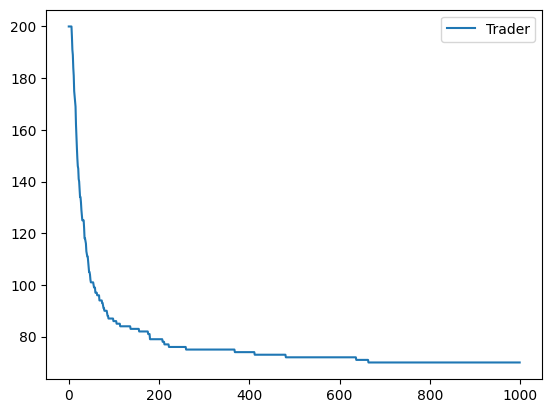

In [72]:
results.plot(y = "Trader", use_index=True)

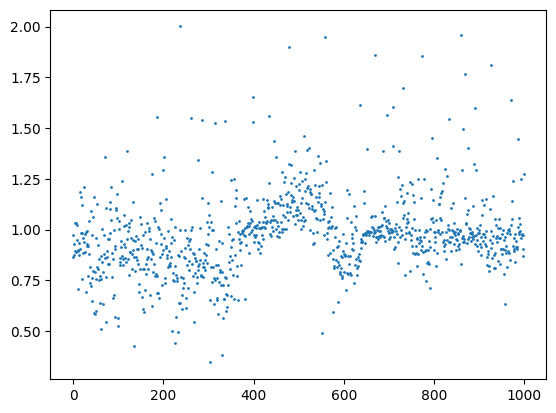

In [73]:
# Plot trade prices

y = list(results["Price"])
x = range(1000)

plt.scatter(x,y, s=1)

<BarContainer object of 999 artists>

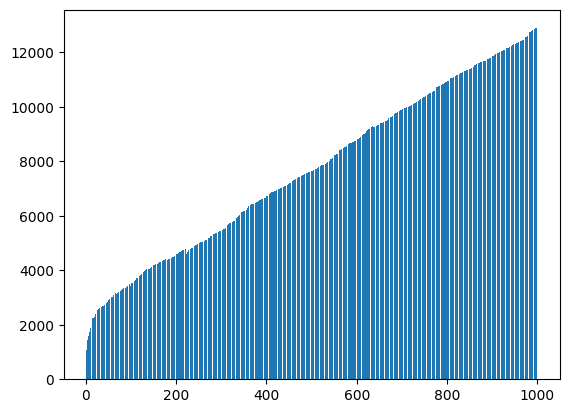

In [74]:
# Plot trade volume

plt.bar(results.index[1:], results["Trade Volume"][1:])

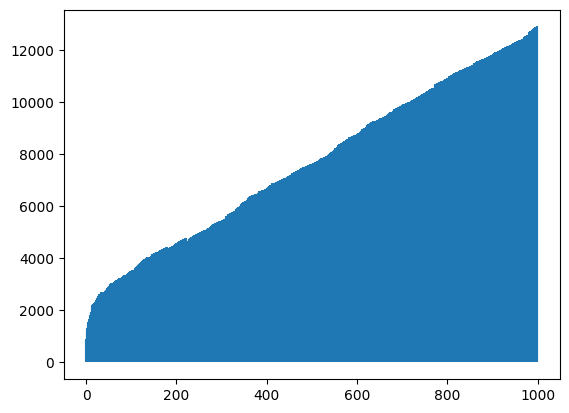

In [75]:
# Plot Trade volume improved

for i in range(1000):
    plt.vlines(i,0,results["Trade Volume"][i])